In [2]:
!pip3 install ipython-sql
!pip3 install mysqlclient

In [3]:
!pip3 install pymysql

In [4]:
!pip install -U pandasql
from pandasql import sqldf

In [31]:
!pip3 install  researchpy

### Importing Libraries

In [2]:
import os
import pymysql
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline
import statsmodels.api as sm
import scipy.stats as stats 
from statsmodels.formula.api import ols
import researchpy as rp

### Connecting to Northwind database in mysql

In [2]:
conn = pymysql.connect(
    host='localhost',
    port=int(3306),
    user="root",
    passwd="Rohith1234#",
    db="northwind",charset='utf8mb4')

## Hypothesis testing

### Question 1:

 Is there any significant difference between the profit generated in <br> 
            (a) Quarter 3 2020 & Quarter 3 2021. <br>
            (b) Quarter 4 2020 & Quarter 4 2021. <br>
            (c) Quarter 1 2021 & Quarter 1 2022. <br>
            (d) Quarter 2 2021 & Quarter 2 2022. <br>

### Loading data into the dataframe df_net_profit_sales

#### loading the Question1 csv file to the data frame df_net_profit_sales and printing all the rows

In [3]:
df_net_profit_sales = pd.read_csv('E:\Question1.csv')

pd.set_option('display.max_rows',df_net_profit_sales.shape[0]+1)
df_net_profit_sales

,OrderID,CustomerID,OrderDate,NetSales,ProductCost,Profit
0,10248,VINET,2020-07-04,566.00,405.0,161.00
1,10249,TOMSP,2020-07-05,2329.25,1863.4,465.85
2,10250,HANAR,2020-07-08,1941.64,1813.0,128.64
3,10251,VICTE,2020-07-08,818.57,670.8,147.77
4,10252,SUPRD,2020-07-09,4497.37,3730.0,767.37
5,10253,HANAR,2020-07-10,1806.00,1444.8,361.20
6,10254,CHOPS,2020-07-11,695.77,625.2,70.57
7,10255,RICSU,2020-07-12,3115.75,2490.5,625.25
8,10256,WELLI,2020-07-15,648.00,517.8,130.20
9,10257,HILAA,2020-07-16,1400.50,1119.9,280.60


### (a) Quarter 3 2020 & Quarter 3 2021

#### Converting OrderDate column to the pandas date format 

In [4]:
df_net_profit_sales['OrderDate'] = pd.to_datetime(df_net_profit_sales['OrderDate'])

#### Extracting and creating a new columns like year, quarter, month, and day in the data frame df_net_profit_sales

In [5]:
df_net_profit_sales['year'] = df_net_profit_sales['OrderDate'].dt.year
df_net_profit_sales['quarter'] = df_net_profit_sales['OrderDate'].dt.quarter
df_net_profit_sales['month'] = df_net_profit_sales['OrderDate'].dt.month
df_net_profit_sales['day'] = df_net_profit_sales['OrderDate'].dt.day

In [6]:
df_net_profit_sales.info() #gives the info of the entire table or data frame

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 830 entries, 0 to 829
Data columns (total 10 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   OrderID      830 non-null    int64         
 1   CustomerID   830 non-null    object        
 2   OrderDate    830 non-null    datetime64[ns]
 3   NetSales     830 non-null    float64       
 4   ProductCost  830 non-null    float64       
 5   Profit       830 non-null    float64       
 6   year         830 non-null    int64         
 7   quarter      830 non-null    int64         
 8   month        830 non-null    int64         
 9   day          830 non-null    int64         
dtypes: datetime64[ns](1), float64(3), int64(5), object(1)
memory usage: 65.0+ KB


In [7]:
df_net_profit_sales.shape #gives the number of rows and columns in the data frame

(830, 10)

In [8]:
df_net_profit_sales['OrderDate'].dt.year.value_counts() #value_counts() gives the number of rows associated with the years 2020, 2021, and 2022 

2021    408
2022    270
2020    152
Name: OrderDate, dtype: int64

In [9]:
df_net_profit_sales # printing the updated df df_net_profit_sales

,OrderID,CustomerID,OrderDate,NetSales,ProductCost,Profit,year,quarter,month,day
0,10248,VINET,2020-07-04,566.00,405.0,161.00,2020,3,7,4
1,10249,TOMSP,2020-07-05,2329.25,1863.4,465.85,2020,3,7,5
2,10250,HANAR,2020-07-08,1941.64,1813.0,128.64,2020,3,7,8
3,10251,VICTE,2020-07-08,818.57,670.8,147.77,2020,3,7,8
4,10252,SUPRD,2020-07-09,4497.37,3730.0,767.37,2020,3,7,9
5,10253,HANAR,2020-07-10,1806.00,1444.8,361.20,2020,3,7,10
6,10254,CHOPS,2020-07-11,695.77,625.2,70.57,2020,3,7,11
7,10255,RICSU,2020-07-12,3115.75,2490.5,625.25,2020,3,7,12
8,10256,WELLI,2020-07-15,648.00,517.8,130.20,2020,3,7,15
9,10257,HILAA,2020-07-16,1400.50,1119.9,280.60,2020,3,7,16


#### Grouping Quarters Q3 with years 2020 & 2021

In [10]:
q3_2020 = df_net_profit_sales[(df_net_profit_sales['quarter']==3) & (df_net_profit_sales['year']==2020)]
q3_2021 = df_net_profit_sales[(df_net_profit_sales['quarter']==3) & (df_net_profit_sales['year']==2021)]

In [11]:
q3_2020 #prints only 2020 quarter 3 data 

,OrderID,CustomerID,OrderDate,NetSales,ProductCost,Profit,year,quarter,month,day
0,10248,VINET,2020-07-04,566.00,405.0,161.00,2020,3,7,4
1,10249,TOMSP,2020-07-05,2329.25,1863.4,465.85,2020,3,7,5
2,10250,HANAR,2020-07-08,1941.64,1813.0,128.64,2020,3,7,8
3,10251,VICTE,2020-07-08,818.57,670.8,147.77,2020,3,7,8
4,10252,SUPRD,2020-07-09,4497.37,3730.0,767.37,2020,3,7,9
5,10253,HANAR,2020-07-10,1806.00,1444.8,361.20,2020,3,7,10
6,10254,CHOPS,2020-07-11,695.77,625.2,70.57,2020,3,7,11
7,10255,RICSU,2020-07-12,3115.75,2490.5,625.25,2020,3,7,12
8,10256,WELLI,2020-07-15,648.00,517.8,130.20,2020,3,7,15
9,10257,HILAA,2020-07-16,1400.50,1119.9,280.60,2020,3,7,16


In [12]:
q3_2021 #prints only 2021 quarter 3 data 

,OrderID,CustomerID,OrderDate,NetSales,ProductCost,Profit,year,quarter,month,day
337,10585,WELLI,2021-07-01,142.50,114.0,28.50,2021,3,7,1
338,10586,REGGC,2021-07-02,23.80,22.4,1.40,2021,3,7,2
339,10587,QUEDE,2021-07-02,807.38,645.4,161.98,2021,3,7,2
340,10588,QUICK,2021-07-03,3120.00,2980.0,140.00,2021,3,7,3
341,10589,GREAL,2021-07-04,72.00,57.6,14.40,2021,3,7,4
342,10590,MEREP,2021-07-07,1101.00,912.0,189.00,2021,3,7,7
343,10591,VAFFE,2021-07-07,812.50,647.0,165.50,2021,3,7,7
344,10592,LEHMS,2021-07-08,516.47,434.5,81.97,2021,3,7,8
345,10593,LEHMS,2021-07-09,1994.40,1994.4,0.00,2021,3,7,9
346,10594,OLDWO,2021-07-09,565.50,452.4,113.10,2021,3,7,9


#### Calculating mean and mean difference of profit column from Q3 2020 & Q3 2021

In [13]:
print('Q3 2020 Mean Profit:', np.mean(q3_2020.Profit))
print('Q3 2021 Mean profit:', np.mean(q3_2021.Profit))
print('Q3 Mean Difference of 2020 & 2021:', np.mean(q3_2021.Profit) - np.mean(q3_2020.Profit))

Q3 2020 Mean Profit: 219.9958571428571
Q3 2021 Mean profit: 215.76097087378642
Q3 Mean Difference of 2020 & 2021: -4.234886269070671


#### Profit Distribution plot of Q3 of years 2020 & 2021

D:\Python\Anaconda\lib\site-packages\seaborn\distributions.py:2557: FutureWarning: `distplot` is a deprecated function and will be removed in a future version. Please adapt your code to use either `displot` (a figure-level function with similar flexibility) or `histplot` (an axes-level function for histograms).
  warnings.warn(msg, FutureWarning)
D:\Python\Anaconda\lib\site-packages\seaborn\distributions.py:2557: FutureWarning: `distplot` is a deprecated function and will be removed in a future version. Please adapt your code to use either `displot` (a figure-level function with similar flexibility) or `histplot` (an axes-level function for histograms).
  warnings.warn(msg, FutureWarning)


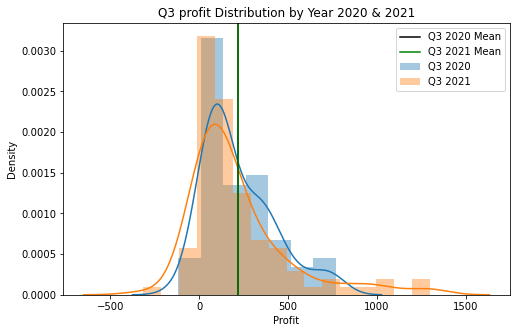

In [14]:
plt.figure(figsize=(8,5))
sns.distplot(q3_2020.Profit, label='Q3 2020')
sns.distplot(q3_2021.Profit, label='Q3 2021')
plt.axvline(np.mean(q3_2020.Profit), color='black', label='Q3 2020 Mean')
plt.axvline(np.mean(q3_2021.Profit), color='green', label='Q3 2021 Mean')
plt.title('Q3 profit Distribution by Year 2020 & 2021')
plt.legend()
plt.show()

### HYPOTHESIS 

Our question is to find if there is an significant difference between the profit generated between the Quarter 3 of years 2020 & 2021

Null Hypothesis (H0): The profit generated of the Q3 2020 is at least equal to the profit generated in Q3 2021.

Alternate Hypothesis (Ha) : The profit generated of the Q3 2021 is greater than the profit generated in Q3 2020.

Significance value (alpha) : 0.05

### Two-Sample t test

In [15]:
import scipy.stats as stats

In [16]:
t_stat, p_val = stats.ttest_ind(q3_2020.Profit, q3_2021.Profit, equal_var=False)
print('P-value:', p_val/2)

P-value: 0.4541440730504983


RESULTS : P-value > significance value

As the p value is greater than the alpha value( significance value) we fail the reject the null hypothesis. so, we cannot say with 95% confidence that there is any significant difference between the Q3 2020 & Q3 2021 generated profit without being due to a random chance.

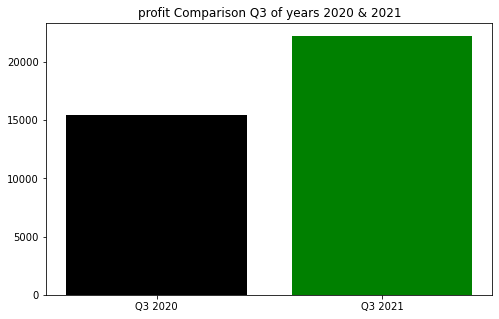

In [17]:
plt.figure(figsize=(8,5))
plt.bar(x='Q3 2020', height = (q3_2020.Profit.sum()), color = ['black'])
plt.bar(x='Q3 2021', height = (q3_2021.Profit.sum()), color = ['green'])
plt.title('profit Comparison Q3 of years 2020 & 2021')
plt.show()

CONCLUSION: The test have failed to reject the null hypothesis and with 95% it cannot be said that profit generated in Q3 2021 is greater than Q3 2020. In the above bar plot it is evident that Q3 2021 profit is more than the Q3 2020 and it can be said that orders in Q3 2021 are more than Q3 2020 and also more net sales are made. But the average profit generated is almost same with difference of 3.07 GBP per order with their respective orders. 

The number of orders in Q3 2021(103 orders) are more than the orders in Q3 2020(70 orders), but the average profit generated in the Q4 in both the years is almost same. <br>
AVG profit in Q3 2020 for 70 orders : 83.24 <br>
AVG profit in Q3 2021 for 103 orders: 86.81 <br>

Finally, testing shows that there is no stastical significant difference in profit generated Q3 2020 and Q3 2021. In Q3 2021, there is more profit generated because of more orders but not due to a random chance.

WHAT IF?
If the orders are more in Q3 2020 than Q3 2021 then the profit generated could be equal. In this situation, it might be a random chance if we fail to reject the Null hypothesis. 

### (b) Quarter 4 2020 & Quarter 4 2021.

In [18]:
df_net_profit_sales

,OrderID,CustomerID,OrderDate,NetSales,ProductCost,Profit,year,quarter,month,day
0,10248,VINET,2020-07-04,566.00,405.0,161.00,2020,3,7,4
1,10249,TOMSP,2020-07-05,2329.25,1863.4,465.85,2020,3,7,5
2,10250,HANAR,2020-07-08,1941.64,1813.0,128.64,2020,3,7,8
3,10251,VICTE,2020-07-08,818.57,670.8,147.77,2020,3,7,8
4,10252,SUPRD,2020-07-09,4497.37,3730.0,767.37,2020,3,7,9
5,10253,HANAR,2020-07-10,1806.00,1444.8,361.20,2020,3,7,10
6,10254,CHOPS,2020-07-11,695.77,625.2,70.57,2020,3,7,11
7,10255,RICSU,2020-07-12,3115.75,2490.5,625.25,2020,3,7,12
8,10256,WELLI,2020-07-15,648.00,517.8,130.20,2020,3,7,15
9,10257,HILAA,2020-07-16,1400.50,1119.9,280.60,2020,3,7,16


#### Grouping Quarters Q4 with years 2020 & 2021

In [19]:
q4_2020 = df_net_profit_sales[(df_net_profit_sales['year']==2020) & ((df_net_profit_sales['month']==10)|(df_net_profit_sales['month']==11)|(df_net_profit_sales['month']==12))]
q4_2021 = df_net_profit_sales[(df_net_profit_sales['year']==2021) & ((df_net_profit_sales['month']==10)|(df_net_profit_sales['month']==11)|(df_net_profit_sales['month']==12))]

In [20]:
q4_2020 #printing the data of Quarter 4 2020

,OrderID,CustomerID,OrderDate,NetSales,ProductCost,Profit,year,quarter,month,day
70,10318,ISLAT,2020-10-01,301.00,240.4,60.60,2020,4,10,1
71,10319,TORTU,2020-10-02,1490.40,1191.2,299.20,2020,4,10,2
72,10320,WARTH,2020-10-03,645.00,516.0,129.00,2020,4,10,3
73,10321,ISLAT,2020-10-03,180.00,144.0,36.00,2020,4,10,3
74,10322,PERIC,2020-10-04,140.00,112.0,28.00,2020,4,10,4
75,10323,KOENE,2020-10-07,205.50,164.4,41.10,2020,4,10,7
76,10324,SAVEA,2020-10-08,6597.68,6155.9,441.78,2020,4,10,8
77,10325,KOENE,2020-10-09,1873.25,1497.0,376.25,2020,4,10,9
78,10326,BOLID,2020-10-10,1227.50,982.0,245.50,2020,4,10,10
79,10327,FOLKO,2020-10-11,2262.92,2122.5,140.42,2020,4,10,11


In [21]:
q4_2021 #printing the data of Quarter 4 2021

,OrderID,CustomerID,OrderDate,NetSales,ProductCost,Profit,year,quarter,month,day
440,10688,VAFFE,2021-10-01,3160.60,2787.2,373.40,2021,4,10,1
441,10689,BERGS,2021-10-01,472.50,504.0,-31.50,2021,4,10,1
442,10690,HANAR,2021-10-02,862.50,920.0,-57.50,2021,4,10,2
443,10691,QUICK,2021-10-03,10164.80,8127.2,2037.60,2021,4,10,3
444,10692,WILMK,2021-10-03,180.00,144.0,36.00,2021,4,10,3
445,10693,WHITC,2021-10-06,2071.20,1863.6,207.60,2021,4,10,6
446,10694,QUICK,2021-10-06,4825.00,3860.0,965.00,2021,4,10,6
447,10695,WILMK,2021-10-07,642.00,513.6,128.40,2021,4,10,7
448,10696,WHITC,2021-10-08,996.00,796.8,199.20,2021,4,10,8
449,10697,LINOD,2021-10-08,805.43,858.7,-53.28,2021,4,10,8


In [22]:
print('Q4 2020 Mean Profit:', np.mean(q4_2020.Profit))
print('Q4 2021 Mean profit:', np.mean(q4_2021.Profit))
print('Q4 Mean Difference of years 2020 & 2021:', np.mean(q4_2021.Profit) - np.mean(q4_2020.Profit))

Q4 2020 Mean Profit: 230.8818292682927
Q4 2021 Mean profit: 225.23516666666674
Q4 Mean Difference of years 2020 & 2021: -5.6466626016259625


D:\Python\Anaconda\lib\site-packages\seaborn\distributions.py:2557: FutureWarning: `distplot` is a deprecated function and will be removed in a future version. Please adapt your code to use either `displot` (a figure-level function with similar flexibility) or `histplot` (an axes-level function for histograms).
  warnings.warn(msg, FutureWarning)
D:\Python\Anaconda\lib\site-packages\seaborn\distributions.py:2557: FutureWarning: `distplot` is a deprecated function and will be removed in a future version. Please adapt your code to use either `displot` (a figure-level function with similar flexibility) or `histplot` (an axes-level function for histograms).
  warnings.warn(msg, FutureWarning)


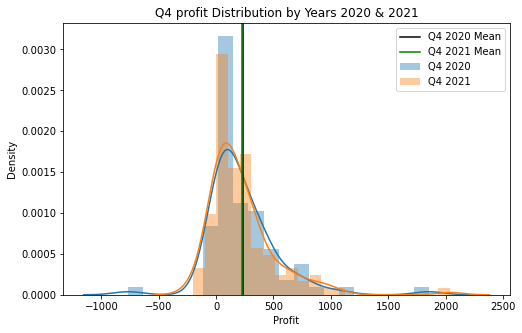

In [23]:
plt.figure(figsize=(8,5))
sns.distplot(q4_2020.Profit, label='Q4 2020')
sns.distplot(q4_2021.Profit, label='Q4 2021')
plt.axvline(np.mean(q4_2020.Profit), color='black', label='Q4 2020 Mean')
plt.axvline(np.mean(q4_2021.Profit), color='green', label='Q4 2021 Mean')
plt.title('Q4 profit Distribution by Years 2020 & 2021')
plt.legend()
plt.show()

### Hypothesis

Our question is to find if there is an significant difference between the profit generated between the Quarter 4 of years 2020 & 2021.

Null Hypothesis (H0): The profit generated of the Q4 2020 is at least equal to the profit generated in Q4 2021. <br>

Alternate Hypothesis (Ha) : The profit generated of the Q4 2021 is greater than the profit generated in Q4 2020. <br>

Significance value (alpha) : 0.05

### Two Sample T-test

In [157]:
t_stat, p_val = stats.ttest_ind(q4_2020.Profit, q4_2021.Profit, equal_var=False)
print('P-value:', p_val/2)

P-value: 0.4490745513286135


RESULTS: The p-value is 0.4490745513286135 which is greater then alpha value( significance value). So, we have failed to reject the null hypothesis and with 95% confidence it cannot be said that the profit generated of Q4 2021 is greater than in Q4 2020 without being due to a random chance. 

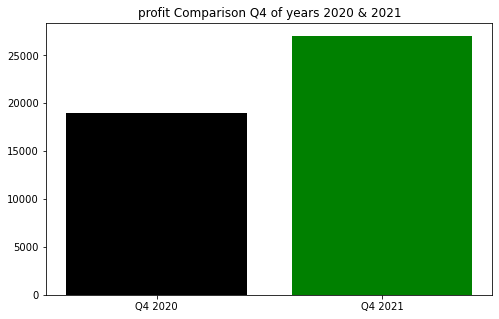

In [75]:
plt.figure(figsize=(8,5))
plt.bar(x='Q4 2020', height = (q4_2020.Profit.sum()), color = ['black'])
plt.bar(x='Q4 2021', height = (q4_2021.Profit.sum()), color = ['green'])
plt.title('profit Comparison Q4 of years 2020 & 2021')
plt.show()

CONCLUSION: The P-value is higher than the alpha value and following the testing rules and considering it as insignificant and we have failed to reject the null hypothesis and with 95% confidence it cannot be said that the profit generated of Q4 2021 is greater than in Q4 2020 without being due to a random chance.

The number of orders in Q4 2021(120 orders) are more than the orders in Q4 2020(82 orders), but the average profit generated in the Q4 in both the years is almost same. <br>
AVG profit in Q4 2020 for 82 orders : 86.06 <br>
AVG profit in Q4 2021 for 120 orders: 87.47  <br>

This shows that most priced products were sold in Q4 2020 with even less number of orders than Q4 2021.

WHAT IF? If the orders are more in Q4 2020 than Q4 2021 then the profit generated could be equal. In this situation, it might be a random chance if we fail to reject the Null hypothesis.

### (c) Quarter 1 2021 & Quarter 1 2022.

#### Grouping Quarters Q1 with years 2021 & 2022

In [76]:
q1_2021 = df_net_profit_sales[(df_net_profit_sales['year']==2021) & ((df_net_profit_sales['month']==1)|(df_net_profit_sales['month']==2)|(df_net_profit_sales['month']==3))]
q1_2022 = df_net_profit_sales[(df_net_profit_sales['year']==2022) & ((df_net_profit_sales['month']==1)|(df_net_profit_sales['month']==2)|(df_net_profit_sales['month']==3))]

In [79]:
print('Q1 2021 Mean Profit:', np.mean(q1_2021.Profit))
print('Q1 2022 Mean profit:', np.mean(q1_2022.Profit))
print('Q1 Mean Difference of the years 2021 & 2022:', np.mean(q1_2021.Profit) - np.mean(q1_2022.Profit))

Q1 2021 Mean Profit: 277.08326086956527
Q1 2022 Mean profit: 258.74912087912094
Q1 Mean Difference of the years 2021 & 2022: 18.334139990444328


D:\Python\Anaconda\lib\site-packages\seaborn\distributions.py:2557: FutureWarning: `distplot` is a deprecated function and will be removed in a future version. Please adapt your code to use either `displot` (a figure-level function with similar flexibility) or `histplot` (an axes-level function for histograms).
  warnings.warn(msg, FutureWarning)
D:\Python\Anaconda\lib\site-packages\seaborn\distributions.py:2557: FutureWarning: `distplot` is a deprecated function and will be removed in a future version. Please adapt your code to use either `displot` (a figure-level function with similar flexibility) or `histplot` (an axes-level function for histograms).
  warnings.warn(msg, FutureWarning)


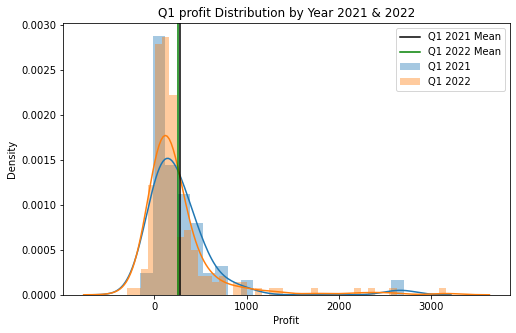

In [80]:
plt.figure(figsize=(8,5))
sns.distplot(q1_2021.Profit, label='Q1 2021')
sns.distplot(q1_2022.Profit, label='Q1 2022')
plt.axvline(np.mean(q1_2021.Profit), color='black', label='Q1 2021 Mean')
plt.axvline(np.mean(q1_2022.Profit), color='green', label='Q1 2022 Mean')
plt.title('Q1 profit Distribution by Year 2021 & 2022')
plt.legend()
plt.show()

### Hypothesis

Our question is to find if there is an significant difference between the profit generated between the Quarter 1 of years 2021 & 2022


Null Hypothesis (H0): The profit generated of the Q1 2021 is at least equal to the profit generated in Q1 2022

Alternate Hypothesis (Ha) : The profit generated of the Q1 2022 is greater than the profit generated in Q1 2021

Significance value (alpha) : 0.05

### Two Sample T-test

In [81]:
t_stat, p_val = stats.ttest_ind(q1_2021.Profit, q1_2022.Profit, equal_var=False)
print('P-value:', p_val/2)

P-value: 0.36923874194597617


RESULTS: As the P-value is greater than the alpha value, we fail to reject the Null hypothesis and cannot say with 95% confidence that Q1 2022 profit generated is greater than the Q1 2021 profit. 

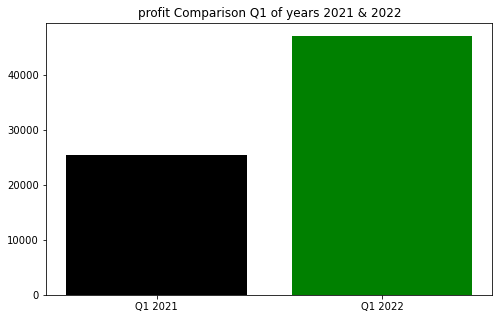

In [82]:
plt.figure(figsize=(8,5))
plt.bar(x='Q1 2021', height = (q1_2021.Profit.sum()), color = ['black'])
plt.bar(x='Q1 2022', height = (q1_2022.Profit.sum()), color = ['green'])
plt.title('profit Comparison Q1 of years 2021 & 2022')
plt.show()

CONCLUSION: The number of orders in Q1 2021(92 orders) are more than the orders in Q1 2022(182 orders), but the average profit generated in the Q1 in both the years is almost same which infact 2021 is higher than the 2022.

AVG profit in Q1 2021 for 92 orders : 105.77 <br>
AVG profit in Q1 2022 for 182 orders: 104.19 <br>

This particular test is the proof that product cost plays an important role in the profit irrespective of the orders.

With the two sample T-test there is not much evidence supporting the alternate hypothesis as the average profit generated in Q1 2021 is greater than the Q1 2022. 

WHAT IF? As the average profit of Q1 2021 is greater than the Q1 2022 even with the very less number of the orders compared to the orders of Q1 2022. If the orders in Q1 2021 are equal as orders in Q1 2022 with these circumstances then this test would have rejected the Null hypothesis. 

### (d) Quarter 2 2021 & Quarter 2 2022.

#### Grouping Quarters Q2 with years 2021 & 2022

In [83]:
q2_2021 = df_net_profit_sales[(df_net_profit_sales['year']==2021) & ((df_net_profit_sales['month']==4)|(df_net_profit_sales['month']==5)|(df_net_profit_sales['month']==6))]
q2_2022 = df_net_profit_sales[(df_net_profit_sales['year']==2022) & ((df_net_profit_sales['month']==4)|(df_net_profit_sales['month']==5)|(df_net_profit_sales['month']==6))]

In [84]:
print('Q2 2021 Mean Profit:', np.mean(q2_2021.Profit))
print('Q2 2022 Mean profit:', np.mean(q2_2022.Profit))
print('Q2 Mean Difference:', np.mean(q2_2021.Profit) - np.mean(q2_2022.Profit))

Q2 2021 Mean Profit: 243.76333333333324
Q2 2022 Mean profit: 213.36818181818182
Q2 Mean Difference: 30.39515151515141


D:\Python\Anaconda\lib\site-packages\seaborn\distributions.py:2557: FutureWarning: `distplot` is a deprecated function and will be removed in a future version. Please adapt your code to use either `displot` (a figure-level function with similar flexibility) or `histplot` (an axes-level function for histograms).
  warnings.warn(msg, FutureWarning)
D:\Python\Anaconda\lib\site-packages\seaborn\distributions.py:2557: FutureWarning: `distplot` is a deprecated function and will be removed in a future version. Please adapt your code to use either `displot` (a figure-level function with similar flexibility) or `histplot` (an axes-level function for histograms).
  warnings.warn(msg, FutureWarning)


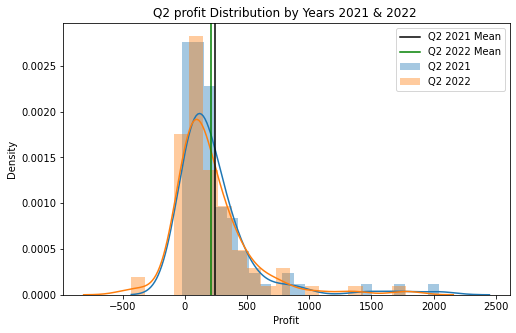

In [85]:
plt.figure(figsize=(8,5))
sns.distplot(q2_2021.Profit, label='Q2 2021')
sns.distplot(q2_2022.Profit, label='Q2 2022')
plt.axvline(np.mean(q2_2021.Profit), color='black', label='Q2 2021 Mean')
plt.axvline(np.mean(q2_2022.Profit), color='green', label='Q2 2022 Mean')
plt.title('Q2 profit Distribution by Years 2021 & 2022 ')
plt.legend()
plt.show()

### Hypothesis

Our question is to find if there is an significant difference between the profit generated between the Quarter 2 of years 2021 & 2022

Null Hypothesis (H0): The profit generated of the Q2 2021 is at least equal to the profit generated in Q2 2022

Alternate Hypothesis (Ha) : The profit generated of the Q2 2022 is greater than the profit generated in Q2 2021

Significance value (alpha) : 0.05

### Two Sample T-test

In [86]:
t_stat, p_val = stats.ttest_ind(q2_2021.Profit, q2_2022.Profit, equal_var=False)
print('P-value:', p_val/2)

P-value: 0.2630548156289514


RESULTS: As the P-value is greater than the alpha value, we fail to reject the Null hypothesis and cannot say with 95% confidence that Q2 2022 profit generated is greater than the Q2 2021 profit.

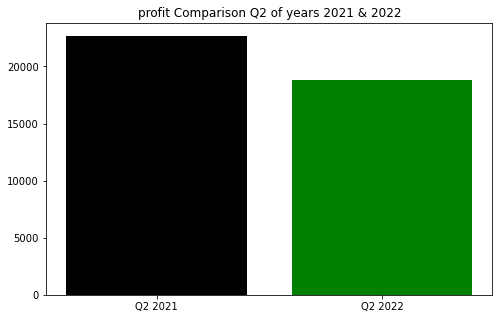

In [87]:
plt.figure(figsize=(8,5))
plt.bar(x='Q2 2021', height = (q2_2021.Profit.sum()), color = ['black'])
plt.bar(x='Q2 2022', height = (q2_2022.Profit.sum()), color = ['green'])
plt.title('profit Comparison Q2 of years 2021 & 2022')
plt.show()

CONCLUSION: The P-value is higher than the alpha value and following the testing rules and considering it as insignificant and we have failed to reject the null hypothesis and with 95% confidence it cannot be said that the profit generated of Q2 2022 is greater than in Q2 2021 without being due to a random chance.

The number of orders in Q2 2021(93 orders) are more than the orders in Q2 2022(88 orders), but the average profit generated in the Q2 in both the years are <br>
AVG profit in Q2 2021 for 93 orders : 89.60 <br>
AVG profit in Q2 2022 for 88 orders: 78.56  <br>

### Question 2

Do the product cost for an order have any significant difference between the customers from different countries in all three years? 

In [3]:
df_cust_product_cost = pd.read_csv('E:\Question2.csv')

pd.set_option('display.max_rows',df_cust_product_cost.shape[0]+1)
df_cust_product_cost

,ShipCountry,CustomerID,TotalProductCost,Quantitysold,TotalOrders
0,Argentina,CACTU,1451,115,6
1,Argentina,OCEAN,2746,132,5
2,Argentina,RANCH,2364,92,5
3,Austria,ERNSH,96076,4543,30
4,Austria,PICCO,23597,624,10
5,Belgium,MAISD,8340,320,7
6,Belgium,SUPRD,22210,1072,12
7,Brazil,COMMI,3679,133,5
8,Brazil,FAMIA,3813,357,7
9,Brazil,GOURL,7110,315,9


In [4]:
df_cust_product_cost.shape

(89, 5)

In [5]:
df_cust_product_cost.isna().sum()

ShipCountry         0
CustomerID          0
TotalProductCost    0
Quantitysold        0
TotalOrders         0
dtype: int64

In [6]:
df_cust_product_cost.ShipCountry.unique()

array(['Argentina', 'Austria', 'Belgium', 'Brazil', 'Canada', 'Denmark',
       'Finland', 'France', 'Germany', 'Ireland', 'Italy', 'Mexico',
       'Norway', 'Poland', 'Portugal', 'Spain', 'Sweden', 'Switzerland',
       'UK', 'USA', 'Venezuela'], dtype=object)

In [7]:
df_cust_product_cost.TotalProductCost.describe()

count       89.000000
mean     12979.932584
std      18507.436088
min        101.000000
25%       2746.000000
50%       6411.000000
75%      15756.000000
max      97449.000000
Name: TotalProductCost, dtype: float64

In [8]:
rp.summary_cont(df_cust_product_cost['TotalProductCost'])

,Variable,N,Mean,SD,SE,95% Conf.,Interval
0,TotalProductCost,89.0,12979.9326,18507.4361,1961.7843,9081.2985,16878.5666


In [9]:
rp.summary_cont(df_cust_product_cost['TotalProductCost'].groupby(df_cust_product_cost['ShipCountry']))

,N,Mean,SD,SE,95% Conf.,Interval
ShipCountry,,,,,,
Argentina,3,2187.0000,665.3969,384.1671,534.0625,3839.9375
Austria,2,59836.5000,51250.3924,36239.5000,-400630.0065,520303.0065
Belgium,2,15275.0000,9807.5711,6935.0000,-72842.5298,103392.5298
Brazil,9,10971.7778,9637.3654,3212.4551,3563.8430,18379.7126
Canada,3,16469.3333,14718.9875,8498.0114,-20094.6585,53033.3252
Denmark,2,15608.0000,1753.6248,1240.0000,-147.6939,31363.6939
Finland,2,8983.0000,8121.8285,5743.0000,-63988.7338,81954.7338
France,10,7461.8000,7054.4104,2230.8004,2415.3788,12508.2212
Germany,11,18448.2727,27701.7009,8352.3771,-161.9832,37058.5286


D:\Python\Anaconda\lib\site-packages\seaborn\distributions.py:2557: FutureWarning: `distplot` is a deprecated function and will be removed in a future version. Please adapt your code to use either `displot` (a figure-level function with similar flexibility) or `histplot` (an axes-level function for histograms).
  warnings.warn(msg, FutureWarning)


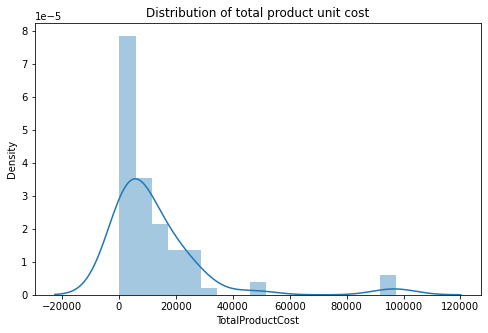

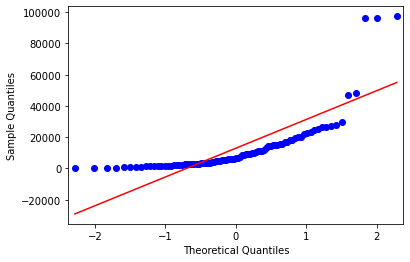

In [10]:
# Visualize data for normality
plt.figure(figsize=(8,5))
sns.distplot(df_cust_product_cost.TotalProductCost)
plt.title('Distribution of total product unit cost')
sm.qqplot(df_cust_product_cost.TotalProductCost, line='s')
plt.show()

### Hypothesis

Our question is to find if there is an significant difference in product cost between different countries.

Null Hypothesis (H0): The effect of product cost between all the countries is equal.

Alternate Hypothesis (Ha) : The effect of product cost between all the countries is not equal.

Significance value (alpha) : 0.05

In [11]:
df_cust_product_cost.TotalProductCost.groupby(df_cust_product_cost.ShipCountry).describe()

,count,mean,std,min,25%,50%,75%,max
ShipCountry,,,,,,,,
Argentina,3.0,2187.000000,665.396874,1451.0,1907.50,2364.0,2555.00,2746.0
Austria,2.0,59836.500000,51250.392394,23597.0,41716.75,59836.5,77956.25,96076.0
Belgium,2.0,15275.000000,9807.571055,8340.0,11807.50,15275.0,18742.50,22210.0
Brazil,9.0,10971.777778,9637.365405,3679.0,5666.00,6181.0,11070.00,27886.0
Canada,3.0,16469.333333,14718.987476,474.0,9982.50,19491.0,24467.00,29443.0
Denmark,2.0,15608.000000,1753.624817,14368.0,14988.00,15608.0,16228.00,16848.0
Finland,2.0,8983.000000,8121.828489,3240.0,6111.50,8983.0,11854.50,14726.0
France,10.0,7461.800000,7054.410359,1338.0,1672.50,5595.0,9654.75,20237.0
Germany,11.0,18448.272727,27701.700901,1161.0,3665.00,9297.0,21674.00,97449.0


Conducting quick One-way ANOVA test on ShipCountry and TotalProductCost which only returns the F-Statistic and P-Value

In [12]:
stats.f_oneway(df_cust_product_cost['TotalProductCost'][df_cust_product_cost['ShipCountry'] == 'Argentina'],
              df_cust_product_cost['TotalProductCost'][df_cust_product_cost['ShipCountry'] == 'Austria'],
              df_cust_product_cost['TotalProductCost'][df_cust_product_cost['ShipCountry'] == 'Belgium'],
              df_cust_product_cost['TotalProductCost'][df_cust_product_cost['ShipCountry'] == 'Brazil'],
               df_cust_product_cost['TotalProductCost'][df_cust_product_cost['ShipCountry'] == 'Canada'],
               df_cust_product_cost['TotalProductCost'][df_cust_product_cost['ShipCountry'] == 'Denmark'],
               df_cust_product_cost['TotalProductCost'][df_cust_product_cost['ShipCountry'] == 'Finland'],
               df_cust_product_cost['TotalProductCost'][df_cust_product_cost['ShipCountry'] == 'France'],
               df_cust_product_cost['TotalProductCost'][df_cust_product_cost['ShipCountry'] == 'Germany'],
               df_cust_product_cost['TotalProductCost'][df_cust_product_cost['ShipCountry'] == 'Ireland'],
               df_cust_product_cost['TotalProductCost'][df_cust_product_cost['ShipCountry'] == 'Italy'],
               df_cust_product_cost['TotalProductCost'][df_cust_product_cost['ShipCountry'] == 'Mexico'],
               df_cust_product_cost['TotalProductCost'][df_cust_product_cost['ShipCountry'] == 'Norway'],
               df_cust_product_cost['TotalProductCost'][df_cust_product_cost['ShipCountry'] == 'Poland'],
               df_cust_product_cost['TotalProductCost'][df_cust_product_cost['ShipCountry'] == 'Portugal'],
               df_cust_product_cost['TotalProductCost'][df_cust_product_cost['ShipCountry'] == 'Spain'],
               df_cust_product_cost['TotalProductCost'][df_cust_product_cost['ShipCountry'] == 'Sweden'],
               df_cust_product_cost['TotalProductCost'][df_cust_product_cost['ShipCountry'] == 'Switzerland'],
               df_cust_product_cost['TotalProductCost'][df_cust_product_cost['ShipCountry'] == 'UK'],
               df_cust_product_cost['TotalProductCost'][df_cust_product_cost['ShipCountry'] == 'USA'],
               df_cust_product_cost['TotalProductCost'][df_cust_product_cost['ShipCountry'] == 'Venezuela'])
               

F_onewayResult(statistic=1.3752412842826331, pvalue=0.16597575961644956)

### One-way ANOVA Test

In [13]:
# ANOVA test
formula = 'TotalProductCost ~ C(ShipCountry)'
lm = ols(formula, df_cust_product_cost).fit()
table = sm.stats.anova_lm(lm, typ=2)
print(table)

                      sum_sq    df         F    PR(>F)
C(ShipCountry)  8.680780e+09  20.0  1.375241  0.165976
Residual        2.146144e+10  68.0       NaN       NaN


RESULTS: From the above one-way ANOVA test table, we can see that F-Statistic is 1.375241 and P-Value is 0.165976. <br>
         As the P-value is greater than the significance value(0.05) we failed to reject the Null hypothesis. So, cannot say            with 95% confidence that product cost is not equal for all the countries. <br>
         
Below let's find the F-critical value and confirm with that at 5% confidence level.

Findng the F-Critical Value at significance value = 0.05

In [14]:
#finding f- critical value
stats.f.ppf(q=1-0.05, dfn=20, dfd=68)

1.72684430722177

Our F-critical value at significance level= 5%, degrees of freedom(numerator)=20 and degrees of freedom(denominator)=68 is 1.72684430722177. <br>

F-statistic < F-Critical value : 1.375241 < 1.72684430722177  <br>

By this it is confirmed that we failed to reject the Null Hypothesis. 

#### Now, let's test  between the USA and Germany as they have the highest product cost, orders, number of customers, and Gross sales and see if there is any significance difference. Note: Can check the charts available in the Power BI file

#### Extracting the USA and GERMANY data

In [15]:
usa_df = df_cust_product_cost[df_cust_product_cost['ShipCountry']=='USA']
germany_df = df_cust_product_cost[df_cust_product_cost['ShipCountry']=='Germany']

In [16]:
usa_df #printing all the rows where ShipCountry is USA

,ShipCountry,CustomerID,TotalProductCost,Quantitysold,TotalOrders
72,USA,GREAL,15756,345,11
73,USA,HUNGC,2627,122,5
74,USA,LAZYK,287,20,2
75,USA,LETSS,2789,181,4
76,USA,LONEP,3549,134,8
77,USA,OLDWO,14365,603,10
78,USA,RATTC,46725,1383,18
79,USA,SAVEA,96448,4958,31
80,USA,SPLIR,11769,327,9
81,USA,THEBI,2756,46,4


In [17]:
germany_df #printing all the rows where ShipCountry is Germany

,ShipCountry,CustomerID,TotalProductCost,Quantitysold,TotalOrders
33,Germany,ALFAA,1161,78,2
34,Germany,BLAUS,2551,140,7
35,Germany,DRACD,3059,160,6
36,Germany,FRANK,25420,1525,15
37,Germany,KOENE,26267,903,14
38,Germany,LEHMS,17928,794,15
39,Germany,MORGK,4271,172,5
40,Germany,OTTIK,11025,639,10
41,Germany,QUICK,97449,3961,28
42,Germany,TOMSP,4503,253,6


#### Calculating total difference in product cost between USA and Germany 

In [18]:
print('Difference in Total product Cost: {}'.format(round(usa_df.TotalProductCost.sum() - germany_df.TotalProductCost.sum(),2)))

Difference in Total product Cost: 22218


#### creating two different bar plots for USA & germany by their Customer ID

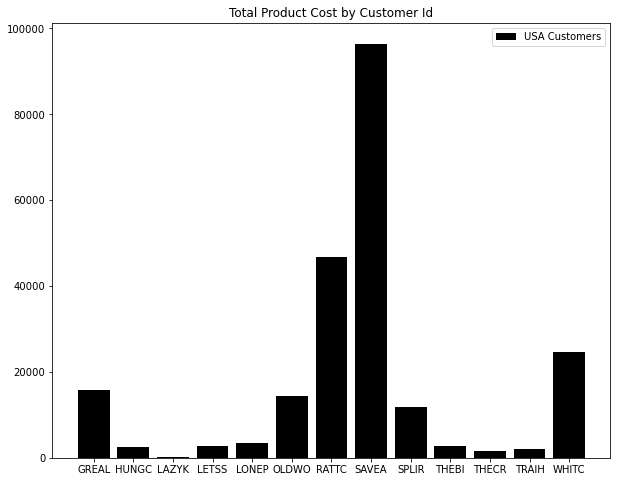

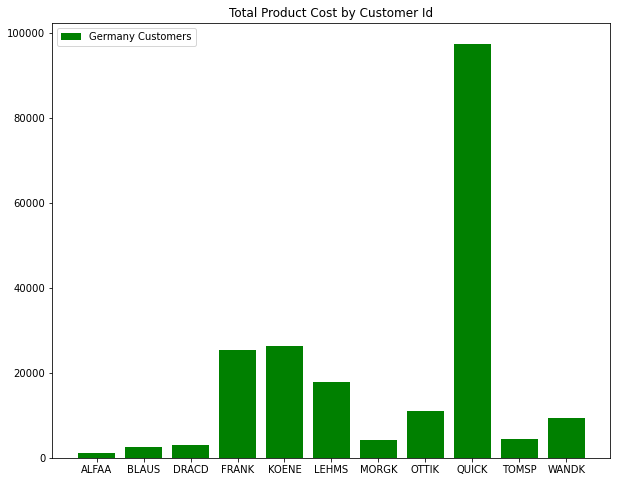

In [40]:
plt.figure(figsize=(10,8))
plt.bar(usa_df.CustomerID, usa_df.TotalProductCost, label='USA Customers', color = 'black')
plt.xticks(usa_df.CustomerID)
plt.title('Total Product Cost by Customer Id')
plt.legend()
plt.show()


plt.figure(figsize=(10,8))
plt.bar(germany_df.CustomerID, germany_df.TotalProductCost, label = 'Germany Customers', color = 'green')
plt.xticks(germany_df.CustomerID)
plt.title('Total Product Cost by Customer Id')
plt.legend()
plt.show()

NOTE: It can be seen that SAVEA from the USA and QUICK from the Germany has the highest product cost 

#### ANOVA test for countries USA & germany with their respective customers

But before that let's import a new dataset df_cust_product_costb where have the usa & germany data with their CustomerID and OrderID as well, because ANOVA cannot their means with CustomerID only as it consists of a single value.

In [43]:
df_cust_product_costb = pd.read_csv('E:\Question2b.csv')

pd.set_option('display.max_rows',df_cust_product_costb.shape[0]+1)
df_cust_product_costb

,ShipCountry,CustomerID,OrderID,TotalProductCost,Quantitysold,TotalOrders
0,Germany,ALFAA,10952,393,18,1
1,Germany,ALFAA,11011,768,60,1
2,Germany,BLAUS,10501,118,20,1
3,Germany,BLAUS,10509,109,3,1
4,Germany,BLAUS,10582,264,18,1
5,Germany,BLAUS,10614,332,27,1
6,Germany,BLAUS,10853,500,10,1
7,Germany,BLAUS,10956,542,34,1
8,Germany,BLAUS,11058,686,28,1
9,Germany,DRACD,10363,447,44,1


In [44]:
usa_dfb = df_cust_product_costb[df_cust_product_costb['ShipCountry']=='USA']
germany_dfb = df_cust_product_costb[df_cust_product_costb['ShipCountry']=='Germany']

In [48]:
print('Difference in Total product Cost: {}'.format(round(usa_dfb.TotalProductCost.sum() - germany_dfb.TotalProductCost.sum(),2)))

Difference in Total product Cost: 22219


Above here we have got the same difference as before so the data taken the second time is the correct one.

In [45]:
usa_dfb

,ShipCountry,CustomerID,OrderID,TotalProductCost,Quantitysold,TotalOrders
118,USA,GREAL,10528,308,20,1
119,USA,GREAL,10589,58,4,1
120,USA,GREAL,10616,4026,59,1
121,USA,GREAL,10617,1320,30,1
122,USA,GREAL,10656,535,37,1
123,USA,GREAL,10681,1060,70,1
124,USA,GREAL,10816,7112,50,1
125,USA,GREAL,10936,456,30,1
126,USA,GREAL,11006,313,10,1
127,USA,GREAL,11040,160,20,1


In [46]:
germany_dfb

,ShipCountry,CustomerID,OrderID,TotalProductCost,Quantitysold,TotalOrders
0,Germany,ALFAA,10952,393,18,1
1,Germany,ALFAA,11011,768,60,1
2,Germany,BLAUS,10501,118,20,1
3,Germany,BLAUS,10509,109,3,1
4,Germany,BLAUS,10582,264,18,1
5,Germany,BLAUS,10614,332,27,1
6,Germany,BLAUS,10853,500,10,1
7,Germany,BLAUS,10956,542,34,1
8,Germany,BLAUS,11058,686,28,1
9,Germany,DRACD,10363,447,44,1


### HYPOTHESIS

Our question is to find if there is an significant difference in product cost between the customers in the countries USA and Germany.

Null Hypothesis (H0): The effect of product cost between all the customers in USA is equal.

Alternate Hypothesis (Ha) : The effect of product cost between all the customers in USA is not equal.

Significance value (alpha) : 0.05

In [51]:
# ANOVA test for usa_dfb (only usa customers)

formula = 'TotalProductCost ~ C(CustomerID)'
lm = ols(formula, usa_dfb).fit()
table = sm.stats.anova_lm(lm, typ=2)
print(table)

                     sum_sq     df         F    PR(>F)
C(CustomerID)  1.200313e+08   12.0  2.566738  0.004882
Residual       4.325685e+08  111.0       NaN       NaN


RESULTS: From the above one-way ANOVA test table, we can see that F-Statistic is 2.566738 and P-Value is 0.004882.
As the P-value is less than the significance value(0.05) we reject the Null hypothesis. So, with 95% confidence that product cost is not equal for all the customers in USA.

Similarily as before let's find out the F-critical value at 5% significance level

In [50]:
#finding f- critical value
stats.f.ppf(q=1-0.05, dfn=12, dfd=111)

1.8403981346888174

Our F-critical value at significance level= 5%, degrees of freedom(numerator)=12 and degrees of freedom(denominator)=111 is 1.8403981346888174.

F-statistic > F-Critical value : 2.566738 > 1.8403981346888174

By this it is confirmed that we reject the Null Hypothesis.

Similarily let's test it for customers in germany and hypothesis is 

Null Hypothesis (H0): The effect of product cost between all the customers in Germany is equal.

Alternate Hypothesis (Ha) : The effect of product cost between all the customers in Germany is not equal.

Significance value (alpha) : 0.05

In [52]:
# ANOVA test for germany_dfb (only germany customers)

formula = 'TotalProductCost ~ C(CustomerID)'
lm = ols(formula, germany_dfb).fit()
table = sm.stats.anova_lm(lm, typ=2)
print(table)

                     sum_sq     df         F    PR(>F)
C(CustomerID)  1.349305e+08   10.0  4.204244  0.000063
Residual       3.434044e+08  107.0       NaN       NaN


RESULTS: From the above one-way ANOVA test table, we can see that F-Statistic is 4.204244 and P-Value is 0.000063. As the P-value is very less than the significance value(0.05) we reject the Null hypothesis. So, with 95% confidence that product cost is not equal for all the customers in Germany.

let's find out the F-critical value at 5% significance level and confirm

In [53]:
stats.f.ppf(q=1-0.05, dfn=10, dfd=107)

1.9203098769827758

Our F-critical value at significance level= 5%, degrees of freedom(numerator)=10 and degrees of freedom(denominator)=107 is 1.9203098769827758.

F-statistic > F-Critical value : 4.204244 > 1.9203098769827758

By this it is confirmed that we reject the Null Hypothesis.

CONCLUSIONS: Based on our overall findings, there is no statistical significance difference in product cost on different countries. It can be seen in the first One-way ANOVA test that is performed above and F-Statistic and P-value justifies it. But the countries like USA, Germany, Austria are in the top with their Profit, Gross & Net sales, and as well as Product cost. Proper conclusions cannot be made with this

To dig deeper, taken the top two countries like USA & germany and performed an one-way ANOVA test on Customer level with the total product cost. This time it is found that there is an statistical difference between the customers in USA & Germany on their product cost. This time P-value and F-statistic proves it that the company QUICK-Stop from germany and Save-a-lot markets from USA have more orders compared to other countries resulting in more Net Sales and profit.

Suggestions: Northwind traders should more focus on selling their products to the customers in the USA and Germany especially to the companies like QUICK-Stop & Save-a-lot markets with more offers and discounts as they have product buying cost is higher compared to other companies.